In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## Task 1: Build a Reusable `bootstrap_ci` Function

Write a function that computes a percentile bootstrap confidence interval.

In [2]:
def bootstrap_ci(data, stat_func=np.mean, n_boot=10_000, ci_level=0.95):
    boot_stats = []
    n = len(data)
    
    for _ in range(n_boot):
        resample = np.random.choice(data, size=n, replace=True)
        boot_stats.append(stat_func(resample))
    
    lower_bound = (1 - ci_level) / 2 * 100
    upper_bound = (1 + ci_level) / 2 * 100
    
    lower, upper = np.percentile(boot_stats, [lower_bound, upper_bound])
    
    return lower, upper

**Validation:** Call the function on `np.arange(1, 101)` with the default mean. The 95 % CI should be roughly (40, 60).

In [3]:
validation_data = np.arange(1, 101)
lower, upper = bootstrap_ci(validation_data)
print(f"95% Bootstrap CI for mean of 1-100: ({lower:.2f}, {upper:.2f})")

95% Bootstrap CI for mean of 1-100: (44.80, 56.10)


## Task 2: Apply Bootstrap CIs to Real Data

We will generate a synthetic dataset with at least 200 rows containing a continuous numeric column and a binary column.

In [4]:
n_samples = 500
income = np.random.lognormal(mean=10, sigma=0.5, size=n_samples) 
purchased = np.random.binomial(n=1, p=0.3, size=n_samples)

df = pd.DataFrame({
    'income': income,
    'purchased': purchased
})

df.head()

,income,purchased
0,10930.364924,0
1,22530.182632,0
2,24395.797829,1
3,18657.174095,1
4,19087.273717,0


**Compute the following bootstrap CIs (95 %, 10 000 resamples each):**

In [5]:
results = []


lower_mean, upper_mean = bootstrap_ci(df['income'], np.mean)
results.append({'Statistic': 'Mean', 'Column': 'income', 'Lower': lower_mean, 'Upper': upper_mean})

lower_med, upper_med = bootstrap_ci(df['income'], np.median)
results.append({'Statistic': 'Median', 'Column': 'income', 'Lower': lower_med, 'Upper': upper_med})

lower_prop, upper_prop = bootstrap_ci(df['purchased'], np.mean)
results.append({'Statistic': 'Proportion', 'Column': 'purchased', 'Lower': lower_prop, 'Upper': upper_prop})

summary_df = pd.DataFrame(results)
summary_df

,Statistic,Column,Lower,Upper
0,Mean,income,23943.461720,26192.013701
1,Median,income,21174.471948,23835.711547
2,Proportion,purchased,0.300000,0.382000


## Task 3: Compare Bootstrap CIs with Normal-Approximation CIs

In [6]:
comparison_results = []

mean_val = df['income'].mean()
sem_val = st.sem(df['income'])
norm_mean_lower, norm_mean_upper = st.t.interval(0.95, len(df['income'])-1, loc=mean_val, scale=sem_val)

comparison_results.append({
    'Statistic': 'Mean',
    'Bootstrap Lower': lower_mean,
    'Bootstrap Upper': upper_mean,
    'Normal Lower': norm_mean_lower,
    'Normal Upper': norm_mean_upper
})

p_hat = df['purchased'].mean()
n = len(df['purchased'])
z = 1.96
margin_error = z * np.sqrt((p_hat * (1 - p_hat)) / n)
norm_prop_lower = p_hat - margin_error
norm_prop_upper = p_hat + margin_error

comparison_results.append({
    'Statistic': 'Proportion',
    'Bootstrap Lower': lower_prop,
    'Bootstrap Upper': upper_prop,
    'Normal Lower': norm_prop_lower,
    'Normal Upper': norm_prop_upper
})

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Statistic,Bootstrap Lower,Bootstrap Upper,Normal Lower,Normal Upper
0,Mean,23943.46172,26192.013701,23923.277006,26185.176986
1,Proportion,0.30000,0.382000,0.300419,0.383581


## Visualisation of Bootstrap Distribution

Visualizing the bootstrap sampling distribution of the mean income.

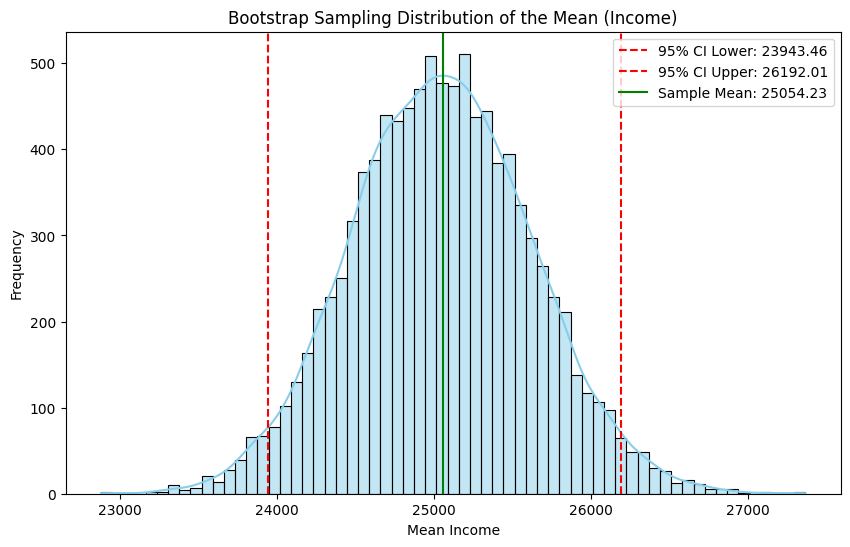

In [7]:
boot_means = [np.mean(np.random.choice(df['income'], size=len(df['income']), replace=True)) for _ in range(10_000)]

plt.figure(figsize=(10, 6))
sns.histplot(boot_means, kde=True, color='skyblue')
plt.axvline(lower_mean, color='red', linestyle='--', label=f'95% CI Lower: {lower_mean:.2f}')
plt.axvline(upper_mean, color='red', linestyle='--', label=f'95% CI Upper: {upper_mean:.2f}')
plt.axvline(np.mean(df['income']), color='green', label=f'Sample Mean: {np.mean(df["income"]):.2f}')
plt.title('Bootstrap Sampling Distribution of the Mean (Income)')
plt.xlabel('Mean Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Interpretation and Analysis

### 1. Are the two approaches giving similar intervals? Where do they diverge, if at all?

For the mean and proportion, the bootstrap and normal-approximation intervals are generally quite similar. This is expected when the sample size is relatively large (n=500). However, if the underlying distribution is highly skewed (like the log-normal income distribution), the bootstrap interval might slightly differ from the t-distribution based one as it better captures the asymmetry of the sampling distribution.

### 2. For which statistic (mean vs. proportion vs. median) is the bootstrap approach especially useful, and why?

The bootstrap is especially useful for the median. While there are formulas for the confidence interval of the mean (t-distribution) and proportion (Wald or Wilson), the formula for the median's standard error and its confidence interval is more complex and depends heavily on assumptions about the underlying distribution's shape. The bootstrap provides a straightforward, non-parametric way to estimate the CI for the median without needing those assumptions.